<a href="https://colab.research.google.com/github/THEJoshinator20/ST-554-Project1-Template/blob/main/Task2/Project1_Task2_JMcClure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project 1 - Task 2
##ST-518
##by Joshua McClure

In [10]:
pip install pingouin

In [11]:
# Installing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from IPython.display import display
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

##What is Task 2?

###This task involves conducting an extensive EDA to understand the relationships the sensor and weather variables have with the C6H6(GT) (benzene) pollutant measurement.

###Importing Dataset and Remove Missing Values

In [12]:
pip install ucimlrepo

In [13]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
air_quality = fetch_ucirepo(id=360)

# data (as pandas dataframes)
X = air_quality.data.features
y = air_quality.data.targets

# metadata
#print(air_quality.metadata)

# variable information
print(air_quality.variables)


             name     role         type demographic  \
0            Date  Feature         Date        None   
1            Time  Feature  Categorical        None   
2          CO(GT)  Feature      Integer        None   
3     PT08.S1(CO)  Feature  Categorical        None   
4        NMHC(GT)  Feature      Integer        None   
5        C6H6(GT)  Feature   Continuous        None   
6   PT08.S2(NMHC)  Feature  Categorical        None   
7         NOx(GT)  Feature      Integer        None   
8    PT08.S3(NOx)  Feature  Categorical        None   
9         NO2(GT)  Feature      Integer        None   
10   PT08.S4(NO2)  Feature  Categorical        None   
11    PT08.S5(O3)  Feature  Categorical        None   
12              T  Feature   Continuous        None   
13             RH  Feature   Continuous        None   
14             AH  Feature   Continuous        None   

                                          description       units  \
0                                                N

###Remove Missing Values / Isolate Variables of Interest

In [14]:
air_quality_df = pd.DataFrame(X)
air_quality_df.head()
#print(air_quality_df.shape)

#Produce copy to ensure data always has consistant source
aqual = air_quality_df.copy()

#Get rid of missing variables labeled as -200 for all variables
#(I am sure there is a neater way but this makes me feel more sure that its done right)
aqual = aqual[~(aqual['CO(GT)'].isin([-200]))]
aqual = aqual[~(aqual['PT08.S1(CO)'].isin([-200]))]
aqual = aqual[~(aqual['NMHC(GT)'].isin([-200]))]
aqual = aqual[~(aqual['C6H6(GT)'].isin([-200]))]
aqual = aqual[~(aqual['PT08.S2(NMHC)'].isin([-200]))]
aqual = aqual[~(aqual['NOx(GT)'].isin([-200]))]
aqual = aqual[~(aqual['PT08.S3(NOx)'].isin([-200]))]
aqual = aqual[~(aqual['NO2(GT)'].isin([-200]))]
aqual = aqual[~(aqual['PT08.S4(NO2)'].isin([-200]))]
aqual = aqual[~(aqual['PT08.S5(O3)'].isin([-200]))]
aqual = aqual[~(aqual['T'].isin([-200]))]
aqual = aqual[~(aqual['RH'].isin([-200]))]
aqual = aqual[~(aqual['AH'].isin([-200]))]

#Reduce model down to variables interested in for Task 2 EDA (Weather, Sensor Data(no "true" variables), Variable C6H6(GT), and Date/Time)
aqual = aqual[['Date', 'Time', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']]
display(aqual)

# Double checking for any missing characters and duplicate rows
print(f"In sorted dataset is there missing values: {aqual.isnull().values.any()}")
print(f"In sorted dataset is there duplicate values: {aqual.duplicated().values.any()}")


,Date,Time,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,1360,11.9,1046,1056,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,1292,9.4,955,1174,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,1402,9.0,939,1140,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,1376,9.2,948,1092,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1272,6.5,836,1205,1490,1110,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...
1226,4/30/2004,20:00:00,1449,19.5,1282,625,2100,1569,19.1,61.1,1.3345
1227,4/30/2004,21:00:00,1363,15.1,1152,684,1951,1495,18.2,65.4,1.3529
1228,4/30/2004,22:00:00,1371,14.6,1136,689,1927,1471,18.1,66.1,1.3579
1229,4/30/2004,23:00:00,1406,13.7,1107,718,1872,1384,17.7,66.9,1.3422


In sorted dataset is there missing values: False
In sorted dataset is there duplicate values: False


Initial EDA for Air Quality Data


*   I took the Date, T, and RH variables and made corosponding categorical variables of them so I could plot them and see how the C6H6(GT) was affected by each one in relation to the other weather sensor variables
*   List item



In [15]:
# Convert 'Date' column to datetime objects
aqual['Date'] = pd.to_datetime(aqual['Date'], format='%m/%d/%Y')

# Create a new 'Month_Year' column
aqual['Month_Year'] = aqual['Date'].dt.to_period('M').astype(str)

# Create variable format for tempurature
def temp(temp_val):
  if temp_val <= 10:
    return "10 Degrees or less"
  elif temp_val <= 20:
    return "10 to 20 Degrees"
  elif temp_val <= 30:
    return "30 Degrees or less"
  else:
    return "30 Degrees or more"

# Apply tempurature format to T to make "Heat" variable
aqual["Heat"] = aqual["T"].apply(temp)

# Create variable format for relative humidity
def humid(hmumid_val):
  if hmumid_val <= 15:
    return "15% or less"
  elif hmumid_val <= 30:
    return "15% to 30%"
  elif hmumid_val <= 45:
    return "30% to 45%"
  elif hmumid_val <= 60:
    return "45% to 60%"
  elif hmumid_val <= 75:
    return "60% to 75%"
  else:
    return "75% Degrees or more"

# Apply relative humidity format to RH to make "Humid" variable
aqual["Humid"] = aqual["RH"].apply(humid)

# Rename columns for OLS functions to get them working
aqualre = aqual.rename(columns={'PT08.S1(CO)': 'PT08_S1_CO', 'C6H6(GT)': 'C6H6_GT', 'PT08.S2(NMHC)' : 'PT08_S2_NMHC', 'PT08.S3(NOx)' : 'PT08_S3_NOx',
                                'PT08.S4(NO2)' : 'PT08_S4_NO2', 'PT08.S5(O3)' : 'PT08_S5_O3'})

# Make OLS model for all weather sensor variable to grab fitted and residual data
aqualmod = smf.ols(formula = 'C6H6_GT ~ PT08_S1_CO + PT08_S2_NMHC + PT08_S3_NOx + PT08_S4_NO2 + PT08_S5_O3', data = aqualre).fit()

aqual['residuals'] = aqualmod.resid
aqual['fitted'] = aqualmod.fittedvalues

display(aqual.describe())

,Date,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,residuals,fitted
count,827,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,827.000000,8.270000e+02,827.000000
mean,2004-04-04 02:50:38.452237056,1207.879081,10.771100,966.116082,963.297461,1600.620314,1045.812576,15.601451,49.050181,0.831853,2.611910e-15,10.771100
min,2004-03-10 00:00:00,753.000000,0.500000,448.000000,461.000000,955.000000,263.000000,6.300000,14.900000,0.402300,-2.331625e+00,-0.340608
25%,2004-03-24 00:00:00,1017.000000,4.800000,754.000000,769.000000,1369.500000,760.000000,11.900000,36.700000,0.718950,-4.628130e-01,4.732473
50%,2004-04-02 00:00:00,1172.000000,9.100000,944.000000,920.000000,1556.000000,1009.000000,15.000000,49.600000,0.817700,-4.805169e-02,9.521294
75%,2004-04-15 00:00:00,1380.000000,14.800000,1142.500000,1131.000000,1783.500000,1320.000000,18.300000,60.550000,0.927500,4.445707e-01,15.385359
max,2004-05-01 00:00:00,2040.000000,39.200000,1754.000000,1935.000000,2679.000000,2359.000000,30.000000,83.200000,1.485200,3.760000e+00,35.948343
std,NaN,241.816997,7.418134,266.424557,265.914168,302.291793,400.134662,4.825304,15.266746,0.178506,7.696973e-01,7.378095


###Finding the best model using AIC, BIC, Adjusted R-squared through OLS (Ordinarty Least Squares)

* Models containing the lowest AIC and BIC while also having the highest Adjusted R-Squared are going to represent the best model possible from the variables in the dataset.


* Usage of this method tells us how the variables react with one another and how they help explain the data as a whole.


* For this part I have listed the best model combinations but at the bottom of the document I have listed all of the combinations.


In [16]:

aqualolsmod = smf.ols(formula = 'C6H6_GT ~ PT08_S2_NMHC', data = aqualre).fit()

print("C6H6_GT ~ PT08_S2_NMHC")
print(f"AIC: {aqualolsmod.aic.round(2)}")
print(f"BIC: {aqualolsmod.bic.round(2)}")
print(f"Adjusted R-Squared: {aqualolsmod.rsquared_adj.round(2)}")
print("\n\n")

aqualolsmod = smf.ols(formula = 'C6H6_GT ~ PT08_S2_NMHC + PT08_S3_NOx', data = aqualre).fit()

print("C6H6_GT ~ PT08_S2_NMHC + PT08_S3_NOx")
print(f"AIC: {aqualolsmod.aic.round(2)}")
print(f"BIC: {aqualolsmod.bic.round(2)}")
print(f"Adjusted R-Squared: {aqualolsmod.rsquared_adj.round(2)}")
print("\n\n")


aqualolsmod = smf.ols(formula = 'C6H6_GT ~ PT08_S2_NMHC + PT08_S3_NOx + PT08_S4_NO2', data = aqualre).fit()

print("C6H6_GT ~ PT08_S2_NMHC + PT08_S3_NOx + PT08_S4_NO2")
print(f"AIC: {aqualolsmod.aic.round(2)}")
print(f"BIC: {aqualolsmod.bic.round(2)}")
print(f"Adjusted R-Squared: {aqualolsmod.rsquared_adj.round(2)}")
print("\n\n")

aqualolsmod = smf.ols(formula = 'C6H6_GT ~ PT08_S1_CO + PT08_S2_NMHC + PT08_S3_NOx + PT08_S4_NO2', data = aqualre).fit()

print("C6H6_GT ~ PT08_S1_CO + PT08_S2_NMHC + PT08_S3_NOx + PT08_S4_NO2")
print(f"AIC: {aqualolsmod.aic.round(2)}")
print(f"BIC: {aqualolsmod.bic.round(2)}")
print(f"Adjusted R-Squared: {aqualolsmod.rsquared_adj.round(2)}")
print("\n\n")

aqualolsmod = smf.ols(formula = 'C6H6_GT ~ PT08_S1_CO + PT08_S2_NMHC + PT08_S3_NOx + PT08_S4_NO2 + PT08_S5_O3', data = aqualre).fit()

print("C6H6_GT ~ PT08_S1_CO + PT08_S2_NMHC + PT08_S3_NOx + PT08_S4_NO2 + PT08_S5_O3")
print(f"AIC: {aqualolsmod.aic.round(2)}")
print(f"BIC: {aqualolsmod.bic.round(2)}")
print(f"Adjusted R-Squared: {aqualolsmod.rsquared_adj.round(2)}")

C6H6_GT ~ PT08_S2_NMHC
AIC: 2767.28
BIC: 2776.72
Adjusted R-Squared: 0.97



C6H6_GT ~ PT08_S2_NMHC + PT08_S3_NOx
AIC: 2277.61
BIC: 2291.76
Adjusted R-Squared: 0.98



C6H6_GT ~ PT08_S2_NMHC + PT08_S3_NOx + PT08_S4_NO2
AIC: 2003.3
BIC: 2022.17
Adjusted R-Squared: 0.99



C6H6_GT ~ PT08_S1_CO + PT08_S2_NMHC + PT08_S3_NOx + PT08_S4_NO2
AIC: 1939.76
BIC: 1963.35
Adjusted R-Squared: 0.99



C6H6_GT ~ PT08_S1_CO + PT08_S2_NMHC + PT08_S3_NOx + PT08_S4_NO2 + PT08_S5_O3
AIC: 1924.98
BIC: 1953.28
Adjusted R-Squared: 0.99


As seen above the model that fits the data best when C6H6 is y would be with all of the weather sensors. This shows that the gasses in the data help to explain the rest of the data. After doing a little bit of digging I found that:

*   Benzene (C6H6(GT)) originates from the burning of many different items such as Oil, wood, gas, propane, ect


*   Tin Oxide PT08.S1(CO) also orginates as an offshoot of the combustion of oil, wood, gas, propane, ect


*   Non-Methane Hydrocarbons PT08.S2(NMHC) also come from burning natural gasses and from natural emissions from the environment


*   Tungsten Oxide PT08.S3(NOx) originates from the mining of ores and is a by product from manufacturing to help reduce emissions for specific gasses (NO2)


*   Nitrogen  Dioxide PT08.S4(NO2) comes from sources like natural gasses and liquids as well as fertilizer and natural animal waste


*   Ozone PT08.S5(O3) comes in many forms the ozone that forms the Ozone layer and the ozone that appears in the level we breathe in


    * The Ozone described is the type that forms in our breathing space which is primarily formed between the interaction of NOx and GT, CO

## Matrix Scatter Plot to show how variable interact with one another

A way of thinking about finding the best model and how things interact togther is through showing a scatter plot of each variable interacting. We can see positive and negative corrleations that will allow us to see how the models above reflect on the variables themselves.

In [17]:
matrix = px.scatter_matrix(aqual, dimensions=["PT08.S1(CO)", "PT08.S2(NMHC)",
                                              "PT08.S3(NOx)", "PT08.S4(NO2)", "PT08.S5(O3)", "Date", "T", "AH", "C6H6(GT)"])

matrix.update_layout(
    title=dict(text='Air Quality Data Set'),
    width=1100,
    height=1100,
)

matrix.show()

For the purposes of this data and the question I am asking we can view this data from using the first row C6H6(GT). Doing so will show the relationships these other varibles will have with C6H6(GT) as well as display the correlation between the variables.


*[C6H6(GT) vs PT08.S1(CO)] - Has a positive relationship, with a normal distribution and the datapoints show no obserable outliers detected


*[C6H6(GT) vs PT08.S2(NMHC)] - Has a positve relationship, with a exponential distribution, datapoints show no obervable outliers


*[C6H6(GT) vs PT08.S3(NOx)] - Has a negative relationship, with a exponential distribution, datapoints show no obervable outliers


*[C6H6(GT) vs PT08.S4(NO2)] - Has a positive relationship, with a normal distribution, datapoints show a observable outlier (The Benzene is unusually high could represent a input error or sensor error, doesn't influence the graph too much)


*[C6H6(GT) vs PT08.S5(O3)] - Has a positive relationship, with a normal distribution and the datapoints show no obserable outliers detected


*[C6H6(GT) vs Date] - No disernable relationship, shows that there are gaps of time where no data is collected, highest points of C6H6(GT) Benzene concetration happen in mid March and the end of April


*[C6H6(GT) vs T] - Somewhat positive relationship, seems that the hotter the tempuature the higher the minimum concentration of Benzene is however the maximum concentration of Benzene seems to be related in part to tempurature


*[C6H6(GT) vs AH] - Somewhat positive relationship, the absolute humidity to Benzene concentration seems to increase more as AH is above 1, like tempurature it is partly related to the Benzene Concentration.

ScatterPlot to show closer the variables Date, T, and AH

In [18]:
fig = px.scatter(aqual, x = "Date", y = "C6H6(GT)")
fig.show()

fig = px.scatter(aqual, x = "T", y = "C6H6(GT)")
fig.show()

fig = px.scatter(aqual, x = "AH", y = "C6H6(GT)")
fig.show()

Using the graphs above I would say that the conclusions we made about the data via the matrix wa correct and there doesn't seem to be any outliers or points of interest that skew the data. However points to note are:


*   In the data for Date there is a 3 day break in March, a 1 day break in early April, and a 5 day break in mid April
    *    This could be caused by the datapoints we had to take away (the missing data), I looked and saw that in 2004 March 19th was Fathers day and Paslm Sunday was April 4th in Italy which could explain the missing data, there are no holidays in April 18th - 22nd that line up with the missing data
*   For the variables T and AH we can see that the distribution of the points is weighted more towards the lower values. For T there are more points below 20 than above it and AH there are more points below 1 than above it.


##Showing the Probability density of C6H6(GT) with other weather sensors in relation to the temperature, relative humidity, and date



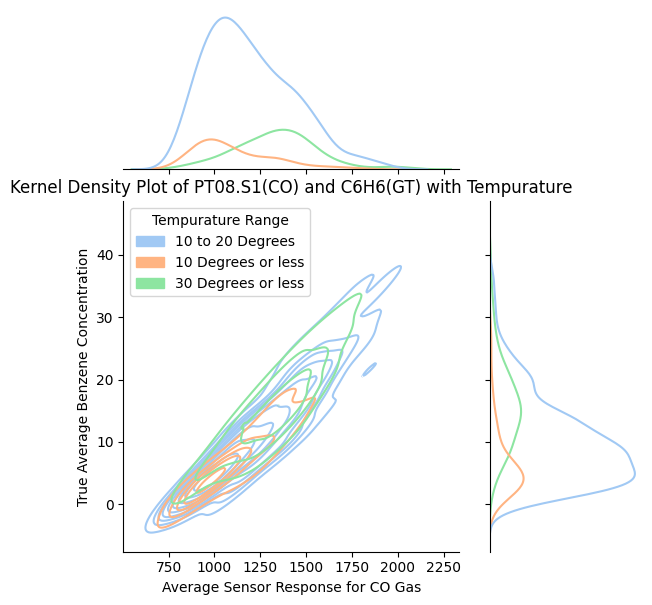

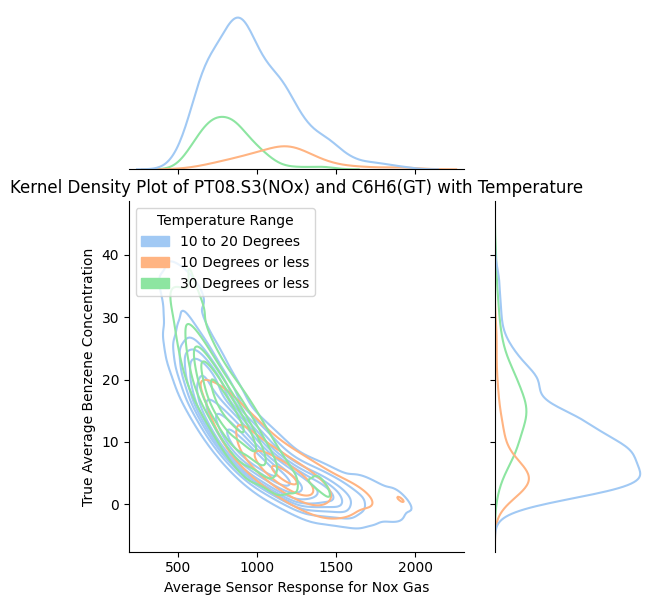

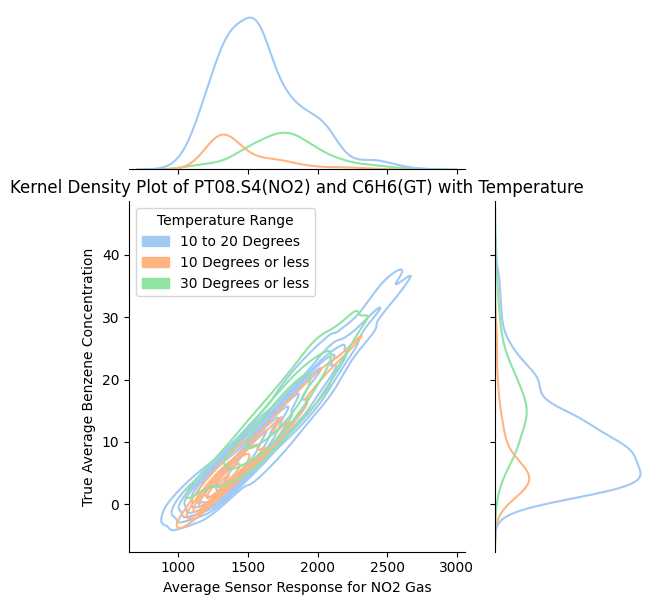

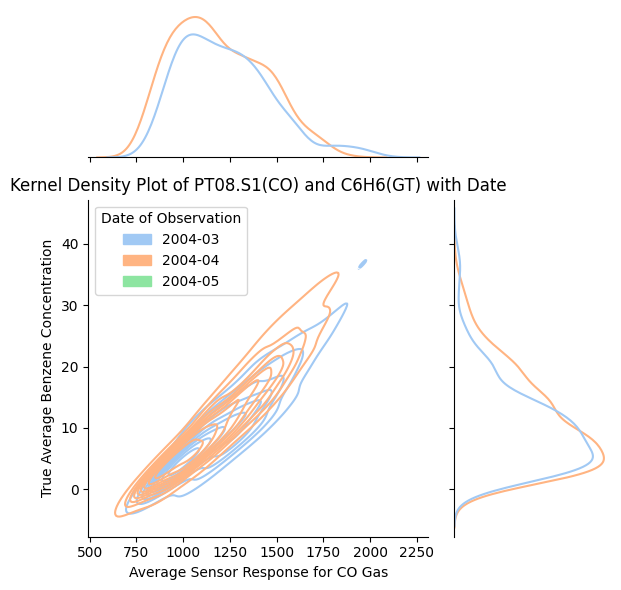

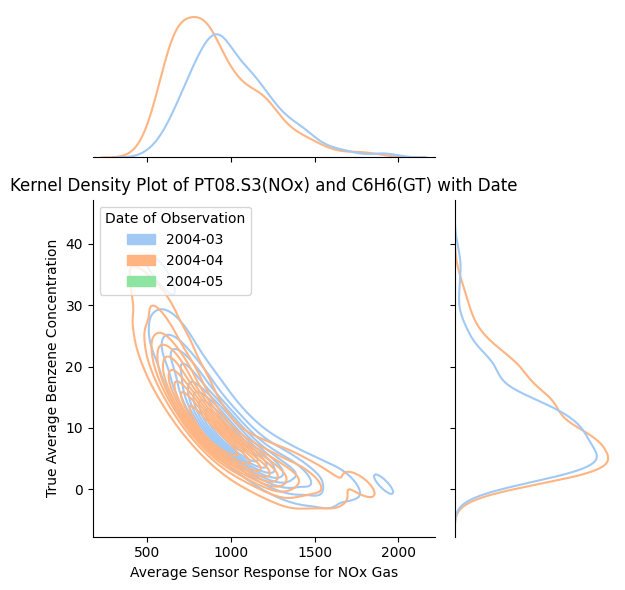

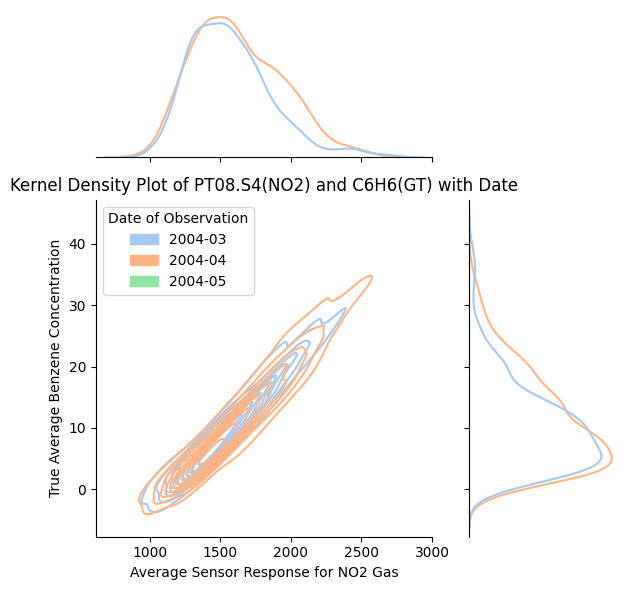

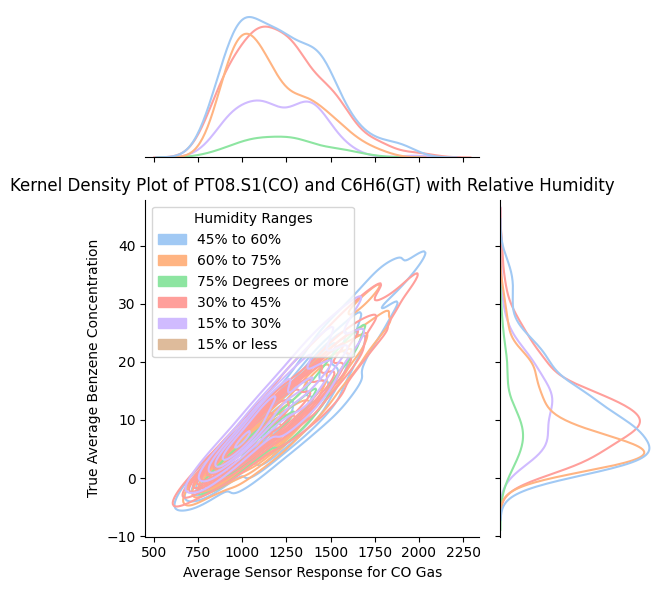

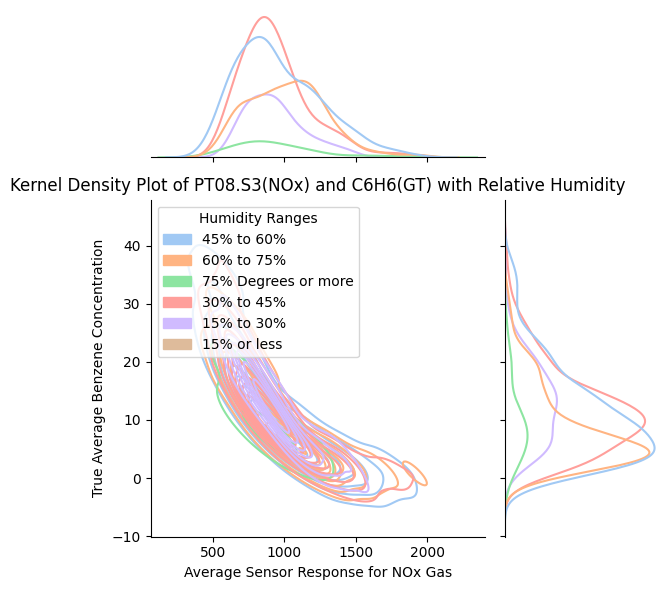

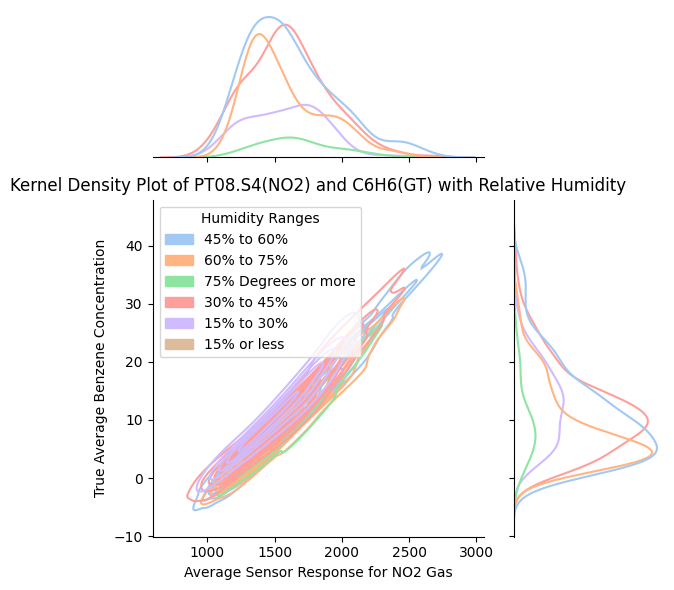

In [19]:
#KDE Plots for y = C6H6(GT) and x = PT08.S1(CO), PT08.S3(NOx), PT08.S4(NO2) with relation to Temperature
#--------------------------------------------------------------------------------------------------------------------------------#

kercpt = sns.jointplot(data = aqual, x = "PT08.S1(CO)", y = "C6H6(GT)", kind = "kde", hue = "Heat", palette= "pastel"
                      , height = 6, ratio = 2)
plt.subplots_adjust(top=1)
plt.ylabel("True Average Benzene Concentration")
plt.xlabel("Average Sensor Response for CO Gas")
plt.title("Kernel Density Plot of PT08.S1(CO) and C6H6(GT) with Tempurature")
# Get unique values for the 'Heat' column to create legend entries
unique_heat_values = aqual['Heat'].unique()

# Get the color palette used by seaborn.jointplot
# The number of colors should match the number of unique hue values
n_colors = len(unique_heat_values)
current_palette = sns.color_palette("pastel", n_colors=n_colors)

# Create a mapping from heat value to color
heat_color_map = dict(zip(unique_heat_values, current_palette))

# Create custom legend handles using mpatches.Patch
legend_handles = [mpatches.Patch(color=heat_color_map[val], label=val) for val in unique_heat_values]

# Add the legend to the jointplot's main axes
kercpt.ax_joint.legend(handles=legend_handles, title='Tempurature Range', loc='upper left')
plt.show()

print("\n\n")

kercpt = sns.jointplot(data = aqual, x = "PT08.S3(NOx)", y = "C6H6(GT)", kind = "kde", hue = "Heat", palette= "pastel"
                      , height = 6, ratio = 2)
plt.subplots_adjust(top=1)
plt.ylabel("True Average Benzene Concentration")
plt.xlabel("Average Sensor Response for Nox Gas")
plt.title("Kernel Density Plot of PT08.S3(NOx) and C6H6(GT) with Temperature")
# Get unique values for the 'Heat' column to create legend entries
unique_heat_values = aqual['Heat'].unique()

# Get the color palette used by seaborn.jointplot
# The number of colors should match the number of unique hue values
n_colors = len(unique_heat_values)
current_palette = sns.color_palette("pastel", n_colors=n_colors)

# Create a mapping from heat value to color
heat_color_map = dict(zip(unique_heat_values, current_palette))

# Create custom legend handles using mpatches.Patch
legend_handles = [mpatches.Patch(color=heat_color_map[val], label=val) for val in unique_heat_values]

# Add the legend to the jointplot's main axes
kercpt.ax_joint.legend(handles=legend_handles, title='Temperature Range', loc='upper left')
plt.show()

print("\n\n")

kercpt = sns.jointplot(data = aqual, x = "PT08.S4(NO2)", y = "C6H6(GT)", kind = "kde", hue = "Heat", palette= "pastel"
                      , height = 6, ratio = 2)
plt.subplots_adjust(top=1)
plt.ylabel("True Average Benzene Concentration")
plt.xlabel("Average Sensor Response for NO2 Gas")
plt.title("Kernel Density Plot of PT08.S4(NO2) and C6H6(GT) with Temperature")
# Get unique values for the 'Heat' column to create legend entries
unique_heat_values = aqual['Heat'].unique()

# Get the color palette used by seaborn.jointplot
# The number of colors should match the number of unique hue values
n_colors = len(unique_heat_values)
current_palette = sns.color_palette("pastel", n_colors=n_colors)

# Create a mapping from heat value to color
heat_color_map = dict(zip(unique_heat_values, current_palette))

# Create custom legend handles using mpatches.Patch
legend_handles = [mpatches.Patch(color=heat_color_map[val], label=val) for val in unique_heat_values]

# Add the legend to the jointplot's main axes
kercpt.ax_joint.legend(handles=legend_handles, title='Temperature Range', loc='upper left')
plt.show()

print("\n\n")

#KDE Plots for y = C6H6(GT) and x = PT08.S1(CO), PT08.S3(NOx), PT08.S4(NO2) with relation to Date
#----------------------------------------------------------------------------------------------------------------------------------#

kercpd = sns.jointplot(data = aqual, x = "PT08.S1(CO)", y = "C6H6(GT)", kind = "kde", hue = "Month_Year", palette= "pastel"
                      , height = 6, ratio = 2)
plt.subplots_adjust(top=1)
plt.ylabel("True Average Benzene Concentration")
plt.xlabel("Average Sensor Response for CO Gas")
plt.title("Kernel Density Plot of PT08.S1(CO) and C6H6(GT) with Date")
# Get unique values for the 'Heat' column to create legend entries
unique_date_values = aqual['Month_Year'].unique()

# Get the color palette used by seaborn.jointplot
# The number of colors should match the number of unique hue values
n_colors = len(unique_date_values)
current_palette = sns.color_palette("pastel", n_colors=n_colors)

# Create a mapping from date value to color
date_color_map = dict(zip(unique_date_values, current_palette))

# Create custom legend handles using mpatches.Patch
legend_handles = [mpatches.Patch(color=date_color_map[val], label=val) for val in unique_date_values]

# Add the legend to the jointplot's main axes
kercpd.ax_joint.legend(handles=legend_handles, title='Date of Observation', loc='upper left')
plt.tight_layout()
plt.show()

print("\n\n")

kercpd = sns.jointplot(data = aqual, x = "PT08.S3(NOx)", y = "C6H6(GT)", kind = "kde", hue = "Month_Year", palette= "pastel"
                      , height = 6, ratio = 2)
plt.subplots_adjust(top=1)
plt.ylabel("True Average Benzene Concentration")
plt.xlabel("Average Sensor Response for NOx Gas")
plt.title("Kernel Density Plot of PT08.S3(NOx) and C6H6(GT) with Date")
# Get unique values for the 'Heat' column to create legend entries
unique_date_values = aqual['Month_Year'].unique()

# Get the color palette used by seaborn.jointplot
# The number of colors should match the number of unique hue values
n_colors = len(unique_date_values)
current_palette = sns.color_palette("pastel", n_colors=n_colors)

# Create a mapping from date value to color
date_color_map = dict(zip(unique_date_values, current_palette))

# Create custom legend handles using mpatches.Patch
legend_handles = [mpatches.Patch(color=date_color_map[val], label=val) for val in unique_date_values]

# Add the legend to the jointplot's main axes
kercpd.ax_joint.legend(handles=legend_handles, title='Date of Observation', loc='upper left')
plt.tight_layout()
plt.show()

print("\n\n")

kercpd = sns.jointplot(data = aqual, x = "PT08.S4(NO2)", y = "C6H6(GT)", kind = "kde", hue = "Month_Year", palette= "pastel"
                      , height = 6, ratio = 2)
plt.subplots_adjust(top=1)
plt.ylabel("True Average Benzene Concentration")
plt.xlabel("Average Sensor Response for NO2 Gas")
plt.title("Kernel Density Plot of PT08.S4(NO2) and C6H6(GT) with Date")
# Get unique values for the 'Heat' column to create legend entries
unique_date_values = aqual['Month_Year'].unique()

# Get the color palette used by seaborn.jointplot
# The number of colors should match the number of unique hue values
n_colors = len(unique_date_values)
current_palette = sns.color_palette("pastel", n_colors=n_colors)

# Create a mapping from date value to color
date_color_map = dict(zip(unique_date_values, current_palette))

# Create custom legend handles using mpatches.Patch
legend_handles = [mpatches.Patch(color=date_color_map[val], label=val) for val in unique_date_values]

# Add the legend to the jointplot's main axes
kercpd.ax_joint.legend(handles=legend_handles, title='Date of Observation', loc='upper left')
plt.tight_layout()
plt.show()

print("\n\n")

#KDE Plots for y = C6H6(GT) and x = PT08.S1(CO), PT08.S3(NOx), PT08.S4(NO2) with relation to relative Humidity
#--------------------------------------------------------------------------------------------------------------------------#

kercpd = sns.jointplot(data = aqual, x = "PT08.S1(CO)", y = "C6H6(GT)", kind = "kde", hue = "Humid", palette= "pastel"
                      , height = 6, ratio = 2)
plt.subplots_adjust(top=1)
plt.ylabel("True Average Benzene Concentration")
plt.xlabel("Average Sensor Response for CO Gas")
plt.title("Kernel Density Plot of PT08.S1(CO) and C6H6(GT) with Relative Humidity")
# Get unique values for the 'Heat' column to create legend entries
unique_date_values = aqual['Humid'].unique()

# Get the color palette used by seaborn.jointplot
# The number of colors should match the number of unique hue values
n_colors = len(unique_date_values)
current_palette = sns.color_palette("pastel", n_colors=n_colors)

# Create a mapping from date value to color
date_color_map = dict(zip(unique_date_values, current_palette))

# Create custom legend handles using mpatches.Patch
legend_handles = [mpatches.Patch(color=date_color_map[val], label=val) for val in unique_date_values]

# Add the legend to the jointplot's main axes
kercpd.ax_joint.legend(handles=legend_handles, title='Humidity Ranges', loc='upper left')
plt.tight_layout()
plt.show()
print("\n\n")

kercpd = sns.jointplot(data = aqual, x = "PT08.S3(NOx)", y = "C6H6(GT)", kind = "kde", hue = "Humid", palette= "pastel"
                      , height = 6, ratio = 2)
plt.subplots_adjust(top=1)
plt.ylabel("True Average Benzene Concentration")
plt.xlabel("Average Sensor Response for NOx Gas")
plt.title("Kernel Density Plot of PT08.S3(NOx) and C6H6(GT) with Relative Humidity")
# Get unique values for the 'Heat' column to create legend entries
unique_date_values = aqual['Humid'].unique()

# Get the color palette used by seaborn.jointplot
# The number of colors should match the number of unique hue values
n_colors = len(unique_date_values)
current_palette = sns.color_palette("pastel", n_colors=n_colors)

# Create a mapping from date value to color
date_color_map = dict(zip(unique_date_values, current_palette))

# Create custom legend handles using mpatches.Patch
legend_handles = [mpatches.Patch(color=date_color_map[val], label=val) for val in unique_date_values]

# Add the legend to the jointplot's main axes
kercpd.ax_joint.legend(handles=legend_handles, title='Humidity Ranges', loc='upper left')
plt.tight_layout()
plt.show()
print("\n\n")

kercpd = sns.jointplot(data = aqual, x = "PT08.S4(NO2)", y = "C6H6(GT)", kind = "kde", hue = "Humid", palette= "pastel"
                      , height = 6, ratio = 2)
plt.subplots_adjust(top=1)
plt.ylabel("True Average Benzene Concentration")
plt.xlabel("Average Sensor Response for NO2 Gas")
plt.title("Kernel Density Plot of PT08.S4(NO2) and C6H6(GT) with Relative Humidity")
# Get unique values for the 'Heat' column to create legend entries
unique_date_values = aqual['Humid'].unique()

# Get the color palette used by seaborn.jointplot
# The number of colors should match the number of unique hue values
n_colors = len(unique_date_values)
current_palette = sns.color_palette("pastel", n_colors=n_colors)

# Create a mapping from date value to color
date_color_map = dict(zip(unique_date_values, current_palette))

# Create custom legend handles using mpatches.Patch
legend_handles = [mpatches.Patch(color=date_color_map[val], label=val) for val in unique_date_values]

# Add the legend to the jointplot's main axes
kercpd.ax_joint.legend(handles=legend_handles, title='Humidity Ranges', loc='upper left')
plt.tight_layout()
plt.show()

The Kernel Density Estimation Plots (KDE) is used to show the shape of a distribution to check for normaility through checking skewness, multimodal behavior, bandwidth, and symmetry. The plot looks similar at a glance however the sideplots are what are important here since they demonstate the normality of the two variables as well as how the temperture, humidity, and the date affect the distribution of the data itself.

Skewness/Symmetry - The data distribution being symmetric or left/right skewed shows how the data is distributed and if it can be a normal distribution

Multimodal - The distribution has one or many peaks that represents how the data reacts to outliers and what can be adjusted to produce a unimodal plot

Bandwidth - Controls the smoothness of the density plot, too large of a bandwidth causes peaks to be smoothed over/rounded out and small bandwidth causes many peaks through wanting to capture all of the datapoints

*  Keep in mind that C6H6(GT) is always left skewed unless said otherwise and the other variable is right skewed unless said otherwise

KDE Plots regarding Temperature:

* [C6H6(GT) vs PT08.S1(CO)]
    * C6H6(GT) - Unimodal for all density plots, good bandwidth no oversmoothing, Largest amount of data comes tempertures between 10-20 degrees, with data coming from 20 - 30 degrees being symetric in nature and taking up the least smount data

    * PT08.S1(CO) - Unimodal for 10 degreees or less and 20-30 degrees but near multimodal with 10-20 degrees plot, good bandwidth possible oversmoothing, Largest amount of data comes tempertures between 10-20 degrees, with data coming from  20 - 30 degrees being symmetric in nature and taking up the least amount of data

* [C6H6(GT) vs PT08.S3(NOx)]
    * C6H6(GT) - Unimodal for all density plots, good bandwidth no oversmoothing, Largest amount of data comes tempertures between 10-20 degrees, with data coming from 20 - 30 degrees being symetric in nature and taking up the least smount data
    
    * PT08.S3(NOx) - Unimodal for 10 degreees or less and 20-30 degrees but near multimodal with 10-20 degrees plot, good bandwidth possible oversmoothing, Largest amount of data comes tempertures between 10-20 degrees, with data coming from 10 degrees or less being symmetric in nature and taking up the least amount of data


* [C6H6(GT) vs PT08.S4(NO2)] - The plot is nearly identical to the [C6H6(GT) vs PT08.S1(CO)] plot only difference is some small differences in data proportion and slight line smoothness. Not enough to touch on but important enough to notice to show a possible relationship between these variables.


KDE Plots Regarding Date

* [C6H6(GT) vs PT08.S1(CO)]
    * C6H6(GT) - Unimodal for both density plots, good bandwidth slight oversmoothing, Largest amount of data from 2004-04 and 2004-03 seems to have an outlier which could be affecting the density plot

    * PT08.S1(CO) - Unimodal for both density plots, the peak for 2004-03 seems to be broad could be an affect from outlier or bandwidth itself, besides that it shows good smoothness indicating a normal bandwidth


* [C6H6(GT) vs PT08.S3(NOx)]
    * C6H6(GT) - Unimodal for both density plots, good bandwidth slight oversmoothing, Largest amount of data from 2004-04 and 2004-03 seems to have an outlier which could be affecting the density plot

    * PT08.S3(Nox) - Unimodal for both density plots good distict peaks for each one, 2004-03 plot to be closer to symmetric could be an efect from the outlier presnted in the data pulling it to the right


* [C6H6(GT) vs PT08.S4(NO2)]
    * C6H6(GT) - Unimodal for both density plots, good bandwidth slight oversmoothing, Largest amount of data from 2004-04 and 2004-03 seems to have an outlier which could be affecting the density plot

    * PT08.S4(NO2) - Unimodal for both density plots, 2004-04 plot doesn't change at all from plot 1 however the 2004-03 plot has a peak nearly identical to 2004-04 which shows an influx of the gas during this month


KDE Plots Regarding Humidity

* [C6H6(GT) vs PT08.S1(CO)]
    * C6H6(GT) - Unimodal for all desnity plots except 15%-30% plot which is bimodal, the data is mostly made from humidity between 30% and 75% while data less than 30% or more than 75%

    * PT08.S1(CO) - Unimodal for all desnity plots except 15%-30% plot which is bimodal, the data is mostly made from humidity between 30% and 75% while data less than 30% or more than 75%, all of the plots are more symmetric and not as skewed


* [C6H6(GT) vs PT08.S3(NOx)]
    * C6H6(GT) - Unimodal for all desnity plots except 15%-30% plot which is bimodal, the data is mostly made from humidity between 30% and 75% while data less than 30% or more than 75%

    * PT08.S3(NOx) - Unimodal for all desnity plots, the data is mostly made from humidity between 30% and 75% while data less than 30% or more than 75%, the 60% to 75% plot is more symmetric but does not have a distinct peak, data as a whole is very skewed


* [C6H6(GT) vs PT08.S4(NO2)] - Plots are almost exactly the same like in the Temperture plots which could indicate correlation between PT08.S1(CO) and PT08.S4(NO2) when C6H6(GT) is the dependent variable.

##Models to help explain the relationship of variables
I figured the models below could help provide some numeric explaination to the KDE Plots that we did above as well as getting a general gist of the correlation between weather sensor variables and Benzene sensor data.

In [20]:
aqualolsmod = smf.ols(formula = 'C6H6_GT ~ PT08_S1_CO', data = aqualre).fit()

print("C6H6_GT ~ PT08_S1_CO")
print(f"AIC: {aqualolsmod.aic.round(2)}")
print(f"BIC: {aqualolsmod.bic.round(2)}")
print(f"Adjusted R-Squared: {aqualolsmod.rsquared_adj.round(2)}")
print("\n\n")

aqualolsmod = smf.ols(formula = 'C6H6_GT ~ PT08_S2_NMHC', data = aqualre).fit()

print("C6H6_GT ~ PT08_S2_NMHC")
print(f"AIC: {aqualolsmod.aic.round(2)}")
print(f"BIC: {aqualolsmod.bic.round(2)}")
print(f"Adjusted R-Squared: {aqualolsmod.rsquared_adj.round(2)}")
print("\n\n")

aqualolsmod = smf.ols(formula = 'C6H6_GT ~ PT08_S3_NOx', data = aqualre).fit()

print("C6H6_GT ~ PT08_S3_NOx")
print(f"AIC: {aqualolsmod.aic.round(2)}")
print(f"BIC: {aqualolsmod.bic.round(2)}")
print(f"Adjusted R-Squared: {aqualolsmod.rsquared_adj.round(2)}")
print("\n\n")

aqualolsmod = smf.ols(formula = 'C6H6_GT ~ PT08_S4_NO2', data = aqualre).fit()

print("C6H6_GT ~ PT08_S4_NO2")
print(f"AIC: {aqualolsmod.aic.round(2)}")
print(f"BIC: {aqualolsmod.bic.round(2)}")
print(f"Adjusted R-Squared: {aqualolsmod.rsquared_adj.round(2)}")
print("\n\n")

aqualolsmod = smf.ols(formula = 'C6H6_GT ~ PT08_S5_O3', data = aqualre).fit()

print("C6H6_GT ~ PT08_S5_O3")
print(f"AIC: {aqualolsmod.aic.round(2)}")
print(f"BIC: {aqualolsmod.bic.round(2)}")
print(f"Adjusted R-Squared: {aqualolsmod.rsquared_adj.round(2)}")
print("\n\n")

aqualolsmod = smf.ols(formula = 'C6H6_GT ~ PT08_S1_CO  + PT08_S4_NO2', data = aqualre).fit()

print("C6H6_GT ~ PT08_S1_CO  + PT08_S4_NO2")
print(f"AIC: {aqualolsmod.aic.round(2)}")
print(f"BIC: {aqualolsmod.bic.round(2)}")
print(f"Adjusted R-Squared: {aqualolsmod.rsquared_adj.round(2)}")
print("\n\n")

aqualolsmod = smf.ols(formula = 'C6H6_GT ~ PT08_S3_NOx + PT08_S4_NO2', data = aqualre).fit()

print("C6H6_GT ~ PT08_S3_NOx + PT08_S4_NO2")
print(f"AIC: {aqualolsmod.aic.round(2)}")
print(f"BIC: {aqualolsmod.bic.round(2)}")
print(f"Adjusted R-Squared: {aqualolsmod.rsquared_adj.round(2)}")
print("\n\n")

aqualolsmod = smf.ols(formula = 'C6H6_GT ~ PT08_S1_CO + PT08_S3_NOx + PT08_S4_NO2', data = aqualre).fit()

print("C6H6_GT ~ PT08_S1_CO + PT08_S3_NOx + PT08_S4_NO2")
print(f"AIC: {aqualolsmod.aic.round(2)}")
print(f"BIC: {aqualolsmod.bic.round(2)}")
print(f"Adjusted R-Squared: {aqualolsmod.rsquared_adj.round(2)}")

C6H6_GT ~ PT08_S1_CO
AIC: 3993.25
BIC: 4002.68
Adjusted R-Squared: 0.87



C6H6_GT ~ PT08_S2_NMHC
AIC: 2767.28
BIC: 2776.72
Adjusted R-Squared: 0.97



C6H6_GT ~ PT08_S3_NOx
AIC: 4610.06
BIC: 4619.5
Adjusted R-Squared: 0.72



C6H6_GT ~ PT08_S4_NO2
AIC: 3542.33
BIC: 3551.77
Adjusted R-Squared: 0.92



C6H6_GT ~ PT08_S5_O3
AIC: 4314.3
BIC: 4323.74
Adjusted R-Squared: 0.8



C6H6_GT ~ PT08_S1_CO  + PT08_S4_NO2
AIC: 3487.4
BIC: 3501.55
Adjusted R-Squared: 0.93



C6H6_GT ~ PT08_S3_NOx + PT08_S4_NO2
AIC: 3543.86
BIC: 3558.02
Adjusted R-Squared: 0.92



C6H6_GT ~ PT08_S1_CO + PT08_S3_NOx + PT08_S4_NO2
AIC: 3488.72
BIC: 3507.59
Adjusted R-Squared: 0.93


 The PT08_S1_CO, PT08_S3_NOx, PT08_S4_NO2 variables have the lowest adjusted R-squared values out of the other sensor data. However when taken together in the same model the adjusted R-Squared becomes some of the best. This means that the variables when taken with C6H6(GT) alone have a good relationship but when compared with other variables it is not the best but when combined together in the same model these variables become highly correlated with one another. This comes with the understanding that these gasses are produced naturally alongside one another from a common source or are used in conjunction iin the creation of another gas.